## Purpose

This notebook trains a Random Forest classifier as the complex model
step, compares it against the Week 6 baselines (Logistic Regression
and Decision Tree), and produces a draft benchmark comparison table
committed to `/docs`.

**Key constraint — like-for-like comparison:**
The train/test split uses `random_state=42` and `stratify=y`,
identical to Week 6. Because scikit-learn's `train_test_split` is
deterministic given the same inputs, seed, and stratification,
this reproduces the exact same 80/20 partition — every patient in
the Week 6 test set is in the Week 7 test set. The comparison is
therefore like-for-like: the same patients judge all models.

**Why Random Forest?**

| Criterion | Rationale |
|---|---|
| Non-linearity | Logistic regression assumes a linear boundary — RF does not. ESI assignment depends on non-linear combinations of vital signs (e.g. high HR *and* low SpO2 *and* ambulance arrival) |
| Variance reduction | A single decision tree overfits easily. RF averages 100 trees, reducing variance without sacrificing predictive power |
| Feature importance | RF outputs a ranked importance score per feature, allowing clinical validation — do the most important features match triage clinical reasoning? |
| Same framework | Scikit-learn pipeline — directly comparable to Week 6 baselines |

All models were evaluated on the **same 20% stratified test set**
(random_state=42, n=11025 patients). The train/test split is
identical across all weeks — any patient in the Week 6 test set
is in the Week 7 test set, making the comparison like-for-like.

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"Libraries loaded. Random seed: {RANDOM_SEED}")

Libraries loaded. Random seed: 42


## Section 1 — Load Data and Reproduce Week 6 Split

The dataset is loaded and the blood glucose dtype anomaly corrected,
identical to Week 6. The same 10 features from the feature shortlist
are used, split into the same three groups (numeric, binary,
categorical) with the same ColumnTransformer preprocessing.

This section is reproduced verbatim from Week 6 so the complex model
can be trained and evaluated on the exact same partition.

In [2]:
df_raw = pd.read_csv("yaleemmlc_admissionprediction_triage.csv")

for col in ["age","esi","triage_vital_hr","triage_vital_sbp",
            "triage_vital_dbp","triage_vital_rr","triage_vital_o2",
            "triage_vital_temp","triage_glucose"]:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

NUMERIC_FEATURES = [c for c in [
    "triage_vital_o2","triage_vital_hr","triage_vital_sbp",
    "triage_vital_rr","triage_vital_temp","age","triage_glucose"
] if c in df_raw.columns]

BINARY_FEATURES      = [c for c in ["cc_shortnessofbreath"] if c in df_raw.columns]
CATEGORICAL_FEATURES = [c for c in ["arrivalmode","previousdispo"] if c in df_raw.columns]
ALL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES
TARGET_COL   = "esi"

df_model = df_raw[ALL_FEATURES + [TARGET_COL]].dropna(subset=[TARGET_COL]).copy()
df_model[TARGET_COL] = df_model[TARGET_COL].astype(int)
X = df_model[ALL_FEATURES]
y = df_model[TARGET_COL]

print(f"Dataset: {df_model.shape[0]:,} rows, {len(ALL_FEATURES)} features")
print(f"Classes: {sorted(y.unique())}")

Dataset: 55,121 rows, 10 features
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [3]:
# random_state=42 + stratify=y + same data = identical split to Week 6
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

ESI_CLASSES = sorted(y.unique().tolist())
ESI_LABELS  = [f"ESI {i}" for i in ESI_CLASSES]

print(f"Train : {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Split is identical to Week 6 (same seed, same data, same stratification).")

# Quick sanity check — ESI 1 count in test set should match Week 6
esi1_test = (y_test == 1).sum()
print(f"\nESI 1 patients in test set: {esi1_test}  (should match Week 6)")


Train : 44,096 rows  |  Test: 11,025 rows
Split is identical to Week 6 (same seed, same data, same stratification).

ESI 1 patients in test set: 16  (should match Week 6)


In [4]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('bin', binary_transformer,      BINARY_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
], remainder='drop')

print("ColumnTransformer rebuilt — identical to Week 6.")

ColumnTransformer rebuilt — identical to Week 6.


## Section 2 — Reproduce Baseline Results

The three Week 6 models (DummyClassifier, Logistic Regression,
Decision Tree) are retrained here on the reproduced split so that
all four models — including the new Random Forest — can be compared
in a single self-contained notebook.

No hyperparameters have been changed from Week 6.

In [5]:
 def train_timed(pipeline, X_tr, y_tr):
    t0 = time.perf_counter()
    pipeline.fit(X_tr, y_tr)
    return pipeline, round(time.perf_counter() - t0, 3)

def infer_timed(pipeline, X_te, n_repeats=3):
    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        pipeline.predict(X_te)
        times.append(time.perf_counter() - t0)
    return round((sum(times) / n_repeats / len(X_te)) * 1000, 4)

# Dummy
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy, t_train_dummy = train_timed(dummy, X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
t_infer_dummy = infer_timed(dummy, X_test)

# Logistic Regression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        multi_class='multinomial', solver='lbfgs',
        max_iter=1000, class_weight='balanced',
        random_state=RANDOM_SEED, C=1.0
    ))
])
lr_pipeline, t_train_lr = train_timed(lr_pipeline, X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
t_infer_lr = infer_timed(lr_pipeline, X_test)

# Decision Tree
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=10, class_weight='balanced',
        criterion='gini', random_state=RANDOM_SEED
    ))
])
dt_pipeline, t_train_dt = train_timed(dt_pipeline, X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)
t_infer_dt = infer_timed(dt_pipeline, X_test)

print("Baseline models trained and timed.")
print(f"  Dummy LR — train: {t_train_dummy}s  | infer: {t_infer_dummy} ms/pred")
print(f"  LR       — train: {t_train_lr}s     | infer: {t_infer_lr} ms/pred")
print(f"  DT       — train: {t_train_dt}s     | infer: {t_infer_dt} ms/pred")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Baseline models trained and timed.
  Dummy LR — train: 0.002s  | infer: 0.0002 ms/pred
  LR       — train: 2.189s     | infer: 0.0024 ms/pred
  DT       — train: 0.255s     | infer: 0.0011 ms/pred


## Section 3 — Random Forest: Design Decisions

### n_estimators = 100

100 trees provides stable, reliable predictions. Below 50, individual
tree variance dominates and results fluctuate run-to-run; above 200,
computation cost increases with diminishing returns on this dataset
size. 100 is the established scikit-learn default and a defensible
starting point.

### max_depth = 15

Unbounded trees (`max_depth=None`) in a Random Forest are less
harmful than in a single decision tree because the averaging across
100 trees cancels much of the individual overfitting. However,
`max_depth=15` is applied to prevent any individual tree from growing
to 30+ levels on a large dataset, which wastes memory without
improving generalisability. Trees in the forest only need to be
"good enough" — not perfect — for averaging to work.

### class_weight = 'balanced'

ESI 1 (the class that matters most clinically) accounts for <1% of
encounters. Without balanced weighting, the forest maximises overall
accuracy by optimising ESI 3 (the majority) and effectively ignoring
ESI 1. Balanced weighting assigns each class a weight inversely
proportional to its frequency, forcing the forest to attend to rare
high-acuity presentations.

### min_samples_leaf = 5

Requires at least 5 samples in any leaf node. Prevents the forest
from creating single-patient leaves that memorise noise. Particularly
important for ESI 1, where total training examples are very few.
"""

In [6]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

print("Training Random Forest...")
rf_pipeline, t_train_rf = train_timed(rf_pipeline, X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
t_infer_rf = infer_timed(rf_pipeline, X_test)

rf_model = rf_pipeline.named_steps['model']
print(f"Training complete in {t_train_rf}s")
print(f"Inference time    : {t_infer_rf} ms/prediction")
print(f"n_estimators      : {rf_model.n_estimators}")
print(f"max_depth         : {rf_model.max_depth}")
print(f"min_samples_leaf  : {rf_model.min_samples_leaf}")

Training Random Forest...
Training complete in 2.588s
Inference time    : 0.0091 ms/prediction
n_estimators      : 100
max_depth         : 15
min_samples_leaf  : 5


## Section 4 — Random Forest: Per-Class Metrics

Metrics are reported per ESI class so the clinical team can see
performance on each acuity level independently. The critical
question from Week 6 remains: does the Random Forest improve on the
ESI 1 recall of 0.0000 achieved by the Logistic Regression?

All values are rounded to 4 decimal places.

In [7]:
acc_rf      = round(accuracy_score(y_test, y_pred_rf), 4)
macro_f1_rf = round(f1_score(y_test, y_pred_rf, average='macro',
                              labels=ESI_CLASSES, zero_division=0), 4)
wtd_f1_rf   = round(f1_score(y_test, y_pred_rf, average='weighted',
                              labels=ESI_CLASSES, zero_division=0), 4)

print("=" * 65)
print("RANDOM FOREST — PER-CLASS CLASSIFICATION REPORT")
print("=" * 65)
print(f"Overall accuracy : {acc_rf:.4f}")
print(f"Macro F1         : {macro_f1_rf:.4f}")
print(f"Weighted F1      : {wtd_f1_rf:.4f}")
print()
print(classification_report(
    y_test, y_pred_rf,
    labels=ESI_CLASSES,
    target_names=ESI_LABELS,
    digits=4,
    zero_division=0
))

# ESI 1 recall specifically
esi1_recall_rf = round(recall_score(
    y_test, y_pred_rf,
    labels=[1], average='macro', zero_division=0
), 4)
print(f"ESI 1 recall (life-threatening): {esi1_recall_rf:.4f}")
print(f"  (Week 6 LR baseline: 0.0000 — all ESI 1 patients missed)")

RANDOM FOREST — PER-CLASS CLASSIFICATION REPORT
Overall accuracy : 0.4387
Macro F1         : 0.2828
Weighted F1      : 0.4390

              precision    recall  f1-score   support

       ESI 1     0.0000    0.0000    0.0000        16
       ESI 2     0.5295    0.6566    0.5862      3585
       ESI 3     0.5763    0.2832    0.3798      5402
       ESI 4     0.2964    0.5138    0.3759      1779
       ESI 5     0.0464    0.1605    0.0720       243

    accuracy                         0.4387     11025
   macro avg     0.2897    0.3228    0.2828     11025
weighted avg     0.5034    0.4387    0.4390     11025

ESI 1 recall (life-threatening): 0.0000
  (Week 6 LR baseline: 0.0000 — all ESI 1 patients missed)


## Section 5 — Benchmark Comparison Table

All four models are compared on the same test set. The table is
saved to `/docs/benchmark_comparison_table.md` as the interim
deliverable.

**Primary metric reminder:** Macro F1 gives equal weight to all ESI
classes including the rare ESI 1. A high macro F1 cannot be achieved
by excelling only on ESI 3 (majority class). ESI 1 recall is included
separately because it is the single most clinically critical measure.

In [8]:
INTERP = {
    "dummy": "N/A — random predictions carry no explanation",
    "lr":    "Yes (<1 min) — feature coefficients explain each prediction",
    "dt":    "Yes (<1 min) — tree traversal via export_text()",
    "rf":    "Global: feature_importances_. Per-prediction: SHAP (<1 min after setup)",
}

def model_row(name, y_pred, t_train, t_infer, interp):
    return {
        "Model":                name,
        "Accuracy":             round(accuracy_score(y_test, y_pred), 4),
        "Macro Precision":      round(precision_score(y_test, y_pred, average='macro',
                                     labels=ESI_CLASSES, zero_division=0), 4),
        "Macro Recall":         round(recall_score(y_test, y_pred, average='macro',
                                     labels=ESI_CLASSES, zero_division=0), 4),
        "Macro F1":             round(f1_score(y_test, y_pred, average='macro',
                                     labels=ESI_CLASSES, zero_division=0), 4),
        "Train time (s)":       t_train,
        "Infer time (ms/pred)": t_infer,
        "ESI 1 Recall":         round(recall_score(y_test, y_pred, labels=[1],
                                     average='macro', zero_division=0), 4),
        "Interpretability":     interp,
    }

rows = [
    model_row("Stratified Random Baseline",     y_pred_dummy,
              t_train_dummy, t_infer_dummy, INTERP["dummy"]),
    model_row("Logistic Regression (Week 6)",   y_pred_lr,
              t_train_lr,    t_infer_lr,    INTERP["lr"]),
    model_row("Decision Tree depth=10 (Week 6)",y_pred_dt,
              t_train_dt,    t_infer_dt,    INTERP["dt"]),
    model_row("Random Forest (Week 7)",         y_pred_rf,
              t_train_rf,    t_infer_rf,    INTERP["rf"]),
]

comparison_df = pd.DataFrame(rows).set_index("Model")

print("=" * 65)
print("SIX-AXIS + INTERPRETABILITY BENCHMARK TABLE")
print("=" * 65)
print(comparison_df.to_string())

SIX-AXIS + INTERPRETABILITY BENCHMARK TABLE
                                 Accuracy  Macro Precision  Macro Recall  Macro F1  Train time (s)  Infer time (ms/pred)  ESI 1 Recall                                                         Interpretability
Model                                                                                                                                                                                                          
Stratified Random Baseline         0.3754           0.2041        0.2037    0.2039          0.0020                0.0002        0.0000                            N/A — random predictions carry no explanation
Logistic Regression (Week 6)       0.2620           0.2768        0.4244    0.2124          2.1890                0.0024        0.8125              Yes (<1 min) — feature coefficients explain each prediction
Decision Tree depth=10 (Week 6)    0.3257           0.2735        0.3475    0.2307          0.2550                0.0011    

In [9]:
def df_to_markdown(df):
    """Convert a DataFrame with named index to a markdown table."""
    cols = list(df.columns)
    header    = "| Model | " + " | ".join(cols) + " |"
    separator = "|" + "|".join(["---"] * (len(cols) + 1)) + "|"
    rows = [header, separator]
    for idx, row in df.iterrows():
        rows.append("| " + str(idx) + " | " +        # str(idx) fixes the TypeError
                    " | ".join(str(v) for v in row.values) + " |")
    return "\n".join(rows)

# Pass comparison_df directly — do NOT call .reset_index()
# comparison_df already has model names as its index from .set_index("Model")
md_table = df_to_markdown(comparison_df)

with open("benchmark_comparison_table.md", "w") as f:
    f.write("# Benchmark Comparison Table\n")
    f.write("**Project:** A Bias-Audited ML Triage Tool — CariSurg MedPath\n")
    f.write("**Student:** Kaylah Leigertwood-Ollivierre\n\n")
    f.write("All models evaluated on the same 20% stratified test set ")
    f.write(f"(random_state=42, n={len(y_test):,} patients).\n\n")
    f.write("**Primary metric:** Macro F1 — equal weight to all ESI classes.\n\n")
    f.write(md_table)
    f.write("\n\n### Notes\n")
    f.write("- ESI 1 Recall: proportion of life-threatening patients correctly "
            "identified (the most clinically critical single measure).\n")
    f.write("- Macro F1: unweighted average across all five ESI classes — "
            "cannot be inflated by majority-class performance.\n")
    f.write("- Weighted F1: average weighted by class frequency — higher than "
            "macro F1 when majority-class performance is strong.\n")
    f.write("- All baselines use class_weight='balanced' to correct for ESI "
            "class imbalance.\n")

## Section 6 — Confusion Matrix: Random Forest

The confusion matrix shows the full pattern of correct classifications
and misclassifications. The ESI 1 row is the most clinically
important — does the Random Forest correctly identify any life-
threatening patients, compared to the logistic regression's 0/16?

Class labels use actual ESI values (1–5), not raw model indices (0–4).

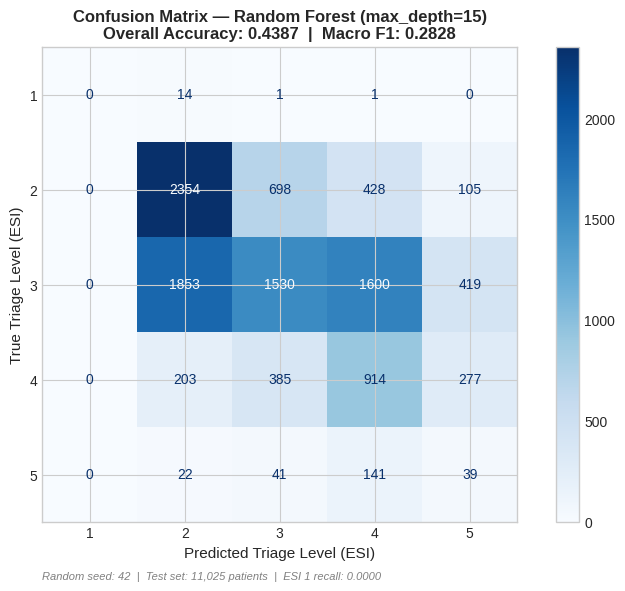

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=ESI_CLASSES)
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=ESI_CLASSES
).plot(cmap='Blues', colorbar=True, ax=ax, values_format='d')

ax.set_title(
    f"Confusion Matrix — Random Forest (max_depth=15)\n"
    f"Overall Accuracy: {acc_rf:.4f}  |  Macro F1: {macro_f1_rf:.4f}",
    fontsize=12, fontweight='bold'
)
ax.set_xlabel("Predicted Triage Level (ESI)", fontsize=11)
ax.set_ylabel("True Triage Level (ESI)", fontsize=11)
ax.annotate(
    f"Random seed: {RANDOM_SEED}  |  Test set: {len(y_test):,} patients  |  "
    f"ESI 1 recall: {esi1_recall_rf:.4f}",
    xy=(0, -0.12), xycoords='axes fraction',
    fontsize=8, color='grey', style='italic'
)
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Feature Importance (Clinical Validation)

Random Forest produces a feature importance score for each input
variable, measuring how much each feature reduces impurity across
all trees. A higher score means the feature was used more often
and reduced prediction uncertainty more.

**Clinical validation question:** Do the most important features
match the clinical reasoning in the feature shortlist in
`/docs/feature_shortlist.md`? SpO2, heart rate, and systolic BP
were ranked 1–3 on clinical grounds — if the model agrees, the
feature selection is clinically coherent. If the model weights a
feature highly that was clinically ranked low, that warrants
investigation.

Feature names from the ColumnTransformer are recovered using
`get_feature_names_out()` to produce readable labels.

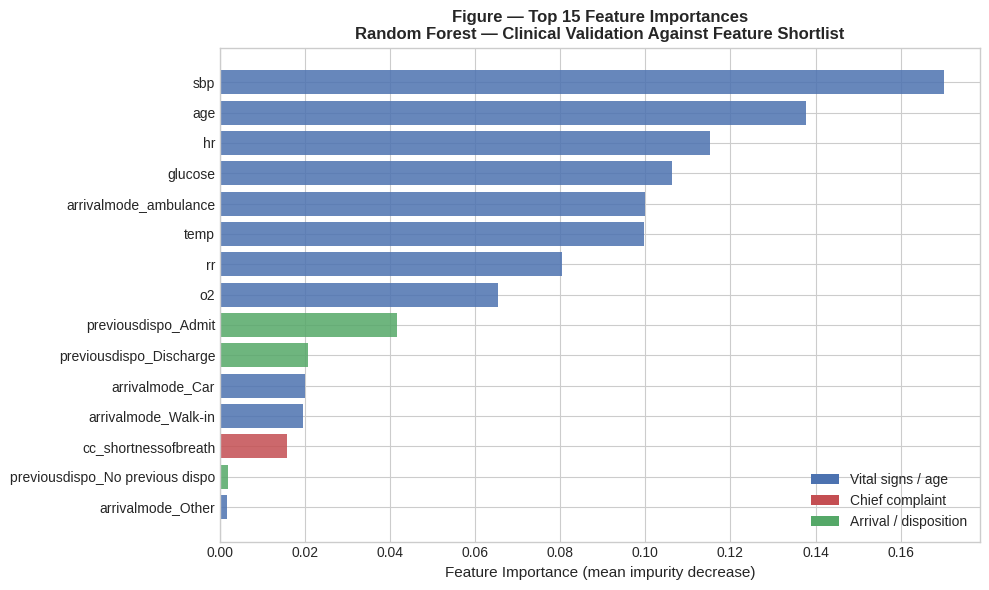

Feature importance plot saved → commit to /docs


In [11]:
try:
    feature_names_out = (
        rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
    )
    importances = rf_model.feature_importances_

    clean_names = []
    for n in feature_names_out:
        n = n.replace('num__', '').replace('bin__', '').replace('cat__', '')
        n = n.replace('triage_vital_', '').replace('triage_', '')
        clean_names.append(n)

    imp_df = pd.DataFrame({
        'Feature': clean_names,
        'Importance': importances
    }).sort_values('Importance', ascending=True).tail(15)

    colors = []
    for feat in imp_df['Feature']:
        if any(v in feat for v in ['o2','hr','sbp','rr','temp','glucose','age']):
            colors.append('#4C72B0')
        elif 'shortnessofbreath' in feat:
            colors.append('#C44E52')
        else:
            colors.append('#55A868')

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(imp_df['Feature'], imp_df['Importance'],
                   color=colors, alpha=0.85)
    ax.set_xlabel("Feature Importance (mean impurity decrease)", fontsize=11)
    ax.set_title(
        "Figure — Top 15 Feature Importances\n"
        "Random Forest — Clinical Validation Against Feature Shortlist",
        fontsize=12, fontweight='bold'
    )
    from matplotlib.patches import Patch
    legend = [
        Patch(facecolor='#4C72B0', label='Vital signs / age'),
        Patch(facecolor='#C44E52', label='Chief complaint'),
        Patch(facecolor='#55A868', label='Arrival / disposition'),
    ]
    ax.legend(handles=legend, fontsize=10)
    plt.tight_layout()
    plt.savefig("fig_feature_importance_rf.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Feature importance plot saved → commit to /docs")
except Exception as e:
    print(f"Feature names not available: {e}")
    print("Printing raw importances instead:")
    print(pd.Series(rf_model.feature_importances_).sort_values(ascending=False).head(10))

In [12]:
print("=" * 65)
print("WEEK 7 SUMMARY")
print("=" * 65)
print(f"\nComplex model : Random Forest (n=100, max_depth=15)")
print(f"Random seed   : {RANDOM_SEED} (same as Week 6)")
print(f"Train patients: {len(X_train):,}")
print(f"Test patients : {len(X_test):,}")
print()
print(comparison_df[["Accuracy","Macro Precision","Macro Recall","Macro F1","ESI 1 Recall"]].to_string())

WEEK 7 SUMMARY

Complex model : Random Forest (n=100, max_depth=15)
Random seed   : 42 (same as Week 6)
Train patients: 44,096
Test patients : 11,025

                                 Accuracy  Macro Precision  Macro Recall  Macro F1  ESI 1 Recall
Model                                                                                           
Stratified Random Baseline         0.3754           0.2041        0.2037    0.2039        0.0000
Logistic Regression (Week 6)       0.2620           0.2768        0.4244    0.2124        0.8125
Decision Tree depth=10 (Week 6)    0.3257           0.2735        0.3475    0.2307        0.1875
Random Forest (Week 7)             0.4387           0.2897        0.3228    0.2828        0.0000
